[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter18_lecture_notebook.ipynb)

# Modelling Financial Markets — Chapter 18: Systemic Risk and Networks

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

This notebook reproduces every chart and table of Lecture 18 on real daily data for 13 banks.

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from scipy.stats import spearmanr
import statsmodels.api as sm
from statsmodels.regression.quantile_regression import QuantReg
from sklearn.linear_model import QuantileRegressor
import warnings
warnings.filterwarnings('ignore')

## Style and helpers

In [2]:
# Stil standard MFM (identic cu SFM): transparent + ENG + legenda jos
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Culori brand
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Teal     = '#17A2B8'
Gray     = '#7F7F7F'   # doar linii de referinta, benzi, grila
REGION_COL = {'US': MainBlue, 'EU': IDAred, 'RO': Forest}
REGION_LAB = {'US': 'US banks', 'EU': 'European banks', 'RO': 'Romanian banks (BVB)'}
EVENTS = [('2011-08-08', 'Euro crisis'), ('2016-06-24', 'Brexit vote'), ('2018-12-19', 'RO bank tax'),
          ('2020-03-16', 'COVID-19'), ('2023-03-13', 'SVB'), ('2025-04-07', 'Tariffs')]

HERE = '.'
SEED = 42
B_BOOT = 200
RESULTS = {}


def save_fig(name):
    """Salveaza figura ca PDF si PNG transparent, in folderul curent."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Plaseaza legenda in afara graficului, jos-centru."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def jsonable(x):
    if isinstance(x, dict):
        return {str(k): jsonable(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [jsonable(v) for v in x]
    if isinstance(x, np.ndarray):
        return [jsonable(v) for v in x.tolist()]
    if isinstance(x, (np.floating, np.integer)):
        return x.item()
    if isinstance(x, pd.Timestamp):
        return str(x.date())
    return x


def mark_events(ax, ymax=None):
    """Linii verticale de referinta pentru evenimente, cu eticheta neagra."""
    for d, lab in EVENTS:
        t = pd.Timestamp(d)
        if ax.get_xlim()[0] <= mdates.date2num(t) <= ax.get_xlim()[1]:
            ax.axvline(t, color=Gray, lw=0.5, ls=':')
            ax.text(t, ax.get_ylim()[1] if ymax is None else ymax, lab, rotation=90, fontsize=6.5, color='black',
                    ha='right', va='top')


import tempfile
HERE = tempfile.gettempdir()   # intermediate tables are written to a temporary folder


def save_fig(name):
    """Show the figure."""
    plt.show()
    plt.close()

## Data

- Daily prices, January 2010 – 18 September 2026: six US banks, five European banks, Banca Transilvania and BRD; S&P 500, Euro Stoxx 50, BET, VIX.
- Prices joined on common trading days, then daily log returns in %; volatility: daily Parkinson range estimator.
- Romanian banks: days without trades removed.

In [3]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# copia locala a folderului data/market, daca notebook-ul ruleaza din repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
START = '2010-01-01'
END = '2026-09-18'

# banca -> (simbol, nume, regiune)
BANKS = {
    'JPM':  ('JPM.US',    'JPMorgan Chase',       'US'),
    'BAC':  ('BAC.US',    'Bank of America',      'US'),
    'C':    ('C.US',      'Citigroup',            'US'),
    'GS':   ('GS.US',     'Goldman Sachs',        'US'),
    'MS':   ('MS.US',     'Morgan Stanley',       'US'),
    'WFC':  ('WFC.US',    'Wells Fargo',          'US'),
    'DBK':  ('DBK.XETRA', 'Deutsche Bank',        'EU'),
    'BNP':  ('BNP.PA',    'BNP Paribas',          'EU'),
    'SAN':  ('SAN.MC',    'Santander',            'EU'),
    'INGA': ('INGA.AS',   'ING',                  'EU'),
    'HSBA': ('HSBA.LSE',  'HSBC',                 'EU'),
    'TLV':  ('TLV.RO',    'Banca Transilvania',   'RO'),
    'BRD':  ('BRD.RO',    'BRD-Groupe SG',        'RO'),
}
US = [k for k, v in BANKS.items() if v[2] == 'US']
EU = [k for k, v in BANKS.items() if v[2] == 'EU']
RO = [k for k, v in BANKS.items() if v[2] == 'RO']
ALL = US + EU + RO
NAMES = {k: v[1] for k, v in BANKS.items()}
INDICES = {'SPX': ('GSPC.INDX', 'S&P 500'), 'SX5E': ('STOXX50E.INDX', 'Euro Stoxx 50'),
           'BET': ('BET', 'BET'), 'VIX': ('VIX.INDX', 'VIX')}
REGION_INDEX = {'US': 'SPX', 'EU': 'SX5E', 'RO': 'BET'}


def read_market(symbol):
    """Citeste data/market/<SIMBOL>.csv local sau din repo-ul GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def bank_frame(key, start=START, end=END):
    """OHLCV al unei banci, cu pretul ajustat si corectiile de mai sus."""
    symbol, _, region = BANKS[key]
    d = read_market(symbol).loc[start:end].copy()
    d = d[(d.index.dayofweek < 5) & (d['adjusted_close'] > 0)]
    if region == 'RO':
        d = d[d['volume'] > 0]                                   # zile fara tranzactii
    if key == 'TLV' and pd.Timestamp('2016-05-30') in d.index:
        # ajustarea pentru actiunile gratuite: factorul de dupa data ex se aplica si pe 30 mai 2016
        f = d.loc['2016-05-31', 'adjusted_close'] / d.loc['2016-05-31', 'close']
        d.loc['2016-05-30', 'adjusted_close'] = d.loc['2016-05-30', 'close'] * f
    return d


def bank_price(key, start=START, end=END):
    return bank_frame(key, start, end)['adjusted_close'].rename(key)


def index_close(key, start=START, end=END):
    s = read_market(INDICES[key][0])['close'].loc[start:end]
    s = s[(s.index.dayofweek < 5) & (s > 0)].dropna()
    if key != 'VIX':
        s = s[s.diff() != 0]                                     # sarbatori completate cu pretul anterior
    return s.rename(key)


def prices(keys, start=START, end=END):
    """Preturi zilnice pentru banci si/sau indici, doar in zilele comune."""
    cols = [bank_price(k, start, end) if k in BANKS else index_close(k, start, end) for k in keys]
    return pd.concat(cols, axis=1, join='inner').dropna()


def joint_returns(keys, start=START, end=END):
    """Randamente log zilnice in %: intai join pe PRETURI in zilele comune, apoi randamente."""
    return 100 * np.log(prices(keys, start, end)).diff().dropna()


def bank_range_vol(keys, start=START, end=END):
    """Volatilitatea zilnica Parkinson (in %, anualizata), in zilele comune tuturor bancilor."""
    out = []
    for k in keys:
        d = bank_frame(k, start, end)
        rng = np.log(d['high'] / d['low']).where(d['high'] > d['low'])
        s2 = rng ** 2 / (4 * np.log(2))
        s2 = s2.fillna(s2[s2 > 0].min())                          # zile cu maxim = minim: cea mai mica valoare observata
        out.append((100 * np.sqrt(252 * s2)).rename(k))
    return pd.concat(out, axis=1, join='inner').dropna()


def system_return(R, members):
    """Randamentul sistemului: portofoliul cu ponderi egale al bancilor (randamente log in %, aproximare zilnica)."""
    return R[members].mean(axis=1)


# randamente log zilnice in % (zile comune) si volatilitatea Parkinson (log)
R = joint_returns(ALL + ['SPX', 'SX5E', 'BET', 'VIX'])
V = np.log(bank_range_vol(ALL))
print(R.index[0].date(), '->', R.index[-1].date(), len(R), 'common days')


def system_ex(k, members):
    """Randamentul sistemului regional fara banca k (portofoliu cu ponderi egale)."""
    return R[[j for j in members if j != k]].mean(axis=1)


def region_of(k):
    return BANKS[k][2]

2010-01-05 -> 2026-09-18 3960 common days


## Systemic risk measures

- `mes`, `lrmes`, `srisk_ratio`, `breakeven_leverage`: exposure measures.
- `qreg`, `covar_static`, `covar_boot`, `covar_dynamic`: CoVaR by quantile regression, with a moving-block bootstrap.
- `var_fit`, `gfevd`, `spillover_table`, `rolling_total`: Diebold–Yilmaz connectedness.
- `lasso_qr_gacv`: L1-penalized quantile regression with the penalty chosen by GACV (Financial Risk Meter).

In [4]:
def mes(r_i, r_m, alpha=0.05):
    """MES (%): pierderea medie a bancii in zilele in care piata este in coada de probabilitate alpha."""
    q = np.quantile(r_m, alpha)
    return -np.mean(np.asarray(r_i)[np.asarray(r_m) <= q])


def mes_threshold(r_i, r_m, c=-2.0):
    """MES (%) in zilele in care piata scade cu mai mult de |c|% (definitia folosita pentru LRMES)."""
    return -np.mean(np.asarray(r_i)[np.asarray(r_m) < c])


def lrmes(mes2_pct):
    """Pierderea pe termen lung intr-o criza (piata -40% in sase luni): LRMES = 1 - exp(-18 MES), MES in fractii."""
    return 1 - np.exp(-18 * mes2_pct / 100)


def srisk_ratio(lrm, leverage, k=0.08):
    """SRISK / capitalul de piata W: k(L - 1) - (1 - k)(1 - LRMES), cu L = (D + W)/W."""
    return k * (leverage - 1) - (1 - k) * (1 - lrm)


def breakeven_leverage(lrm, k=0.08):
    """Levierul L* peste care SRISK > 0: L* = 1 + (1 - k)(1 - LRMES)/k."""
    return 1 + (1 - k) * (1 - lrm) / k


def qreg(y, X, q):
    """Regresie cuantila (Koenker-Bassett); intoarce coeficientii [termen liber, pante]."""
    return QuantReg(np.asarray(y), sm.add_constant(np.asarray(X), has_constant='add')).fit(q=q, max_iter=5000).params


def covar_static(x_sys, x_i, alpha=0.01):
    """CoVaR si Delta-CoVaR necondiționate (%, pozitive = pierderi).

    Regresia cuantila la nivelul alpha: X_sys = a + b X_i;
    CoVaR_alpha = -(a + b q_alpha(X_i)); Delta-CoVaR = b (q_50(X_i) - q_alpha(X_i))."""
    x_sys, x_i = np.asarray(x_sys), np.asarray(x_i)
    a, b = qreg(x_sys, x_i, alpha)
    qa, qm = np.quantile(x_i, alpha), np.quantile(x_i, 0.5)
    return {'a': a, 'b': b, 'var_i': -qa, 'covar': -(a + b * qa), 'covar_med': -(a + b * qm),
            'dcovar': b * (qm - qa), 'var_sys': -np.quantile(x_sys, alpha)}


def block_bootstrap_idx(n, block=20, rng=None):
    """Indici pentru bootstrap pe blocuri mobile (Künsch), blocuri de lungime fixa."""
    rng = rng or np.random.default_rng(0)
    starts = rng.integers(0, n - block + 1, size=int(np.ceil(n / block)))
    return (starts[:, None] + np.arange(block)[None, :]).ravel()[:n]


def covar_boot(x_sys, x_i, alpha=0.01, B=200, block=20, seed=0):
    """Interval percentil de 95% pentru Delta-CoVaR prin bootstrap pe blocuri mobile."""
    x_sys, x_i = np.asarray(x_sys), np.asarray(x_i)
    rng = np.random.default_rng(seed)
    d = []
    for _ in range(B):
        idx = block_bootstrap_idx(len(x_i), block, rng)
        d.append(covar_static(x_sys[idx], x_i[idx], alpha)['dcovar'])
    return np.percentile(d, [2.5, 97.5])


def covar_dynamic(x_sys, x_i, M, alpha=0.01):
    """Delta-CoVaR variabil in timp cu variabile de stare M_{t-1} (Adrian & Brunnermeier, 2016).

    X_i,t = a + c'M_{t-1} la nivelurile alpha si 50%  ->  VaR_i,t;
    X_sys,t = a + b X_i,t + c'M_{t-1} la nivelul alpha  ->  Delta-CoVaR_t = b (q50_i,t - qalpha_i,t)."""
    ci_a = qreg(x_i, M, alpha)
    ci_m = qreg(x_i, M, 0.5)
    cs = qreg(x_sys, np.column_stack([x_i, M]), alpha)
    Mc = sm.add_constant(np.asarray(M), has_constant='add')
    qa, qm = Mc @ ci_a, Mc @ ci_m
    return pd.DataFrame({'var_i': -qa, 'dcovar': cs[1] * (qm - qa)}, index=getattr(x_i, 'index', None)), cs[1]


def var_fit(Y, p):
    """VAR(p) estimat prin OLS; intoarce coeficientii A_1..A_p (k x k) si matricea de covarianta a reziduurilor."""
    Y = np.asarray(Y, float)
    T, k = Y.shape
    X = np.hstack([np.ones((T - p, 1))] + [Y[p - l - 1:T - l - 1] for l in range(p)])
    Yt = Y[p:]
    B = np.linalg.lstsq(X, Yt, rcond=None)[0]
    E = Yt - X @ B
    S = E.T @ E / (len(Yt) - X.shape[1])
    A = [B[1 + l * k:1 + (l + 1) * k].T for l in range(p)]
    return A, S


def var_bic(Y, pmax=5):
    """Ordinul VAR ales prin criteriul BIC."""
    Y = np.asarray(Y, float)
    T, k = Y.shape
    best = None
    for p in range(1, pmax + 1):
        A, S = var_fit(Y[pmax - p:], p)
        n = T - pmax
        bic = np.log(np.linalg.det(S)) + np.log(n) * p * k * k / n
        if best is None or bic < best[1]:
            best = (p, bic)
    return best[0]


def ma_coefs(A, H):
    """Coeficientii reprezentarii medie mobila Phi_0..Phi_{H-1}."""
    k = A[0].shape[0]
    Phi = [np.eye(k)]
    for h in range(1, H):
        Phi.append(sum(A[l] @ Phi[h - l - 1] for l in range(min(h, len(A)))))
    return Phi


def gfevd(A, S, H=10):
    """Descompunerea generalizata a dispersiei erorii de prognoza (Pesaran-Shin), normalizata pe linii."""
    Phi = ma_coefs(A, H)
    k = S.shape[0]
    num = np.zeros((k, k))
    den = np.zeros(k)
    for P in Phi:
        PS = P @ S
        num += PS ** 2
        den += np.diag(P @ S @ P.T)
    theta = num / np.diag(S)[None, :] / den[:, None]
    return theta / theta.sum(axis=1, keepdims=True)


def spillover_table(theta, names):
    """Tabelul de conectivitate: contributii (%), FROM, TO, NET si indicele total."""
    k = theta.shape[0]
    D = 100 * theta
    off = D - np.diag(np.diag(D))
    frm, to = off.sum(axis=1), off.sum(axis=0)
    tab = pd.DataFrame(D, index=names, columns=names)
    return {'table': tab, 'from': pd.Series(frm, index=names), 'to': pd.Series(to, index=names),
            'net': pd.Series(to - frm, index=names), 'total': off.sum() / k,
            'pairwise_net': pd.DataFrame(off.T - off, index=names, columns=names)}


def rolling_total(Y, window=250, step=5, p=2, H=10):
    """Indicele total de conectivitate pe ferestre mobile."""
    Y = pd.DataFrame(Y)
    out, frm_to = {}, {}
    for end in range(window, len(Y) + 1, step):
        w = Y.iloc[end - window:end]
        A, S = var_fit(w.values, p)
        st = spillover_table(gfevd(A, S, H), list(Y.columns))
        out[Y.index[end - 1]] = st['total']
        frm_to[Y.index[end - 1]] = st['net']
    return pd.Series(out), pd.DataFrame(frm_to).T


def check_loss(u, tau):
    return u * (tau - (u < 0))


def lasso_qr_gacv(y, X, tau=0.05, lambdas=None):
    """Regresie cuantila penalizata L1; lambda ales prin GACV = sum rho_tau(rez) / (n - df)."""
    y, X = np.asarray(y, float), np.asarray(X, float)
    n = len(y)
    lambdas = np.logspace(-4, -0.5, 15) if lambdas is None else lambdas
    rows = []
    for lam in lambdas:
        m = QuantileRegressor(quantile=tau, alpha=lam, solver='highs').fit(X, y)
        res = y - m.predict(X)
        df = int(np.sum(np.abs(m.coef_) > 1e-8))
        g = check_loss(res, tau).sum() / max(n - df, 1)
        rows.append((lam, g, df, m.coef_.copy()))
    i = int(np.argmin([r[1] for r in rows]))
    return {'lambda': rows[i][0], 'gacv': [r[1] for r in rows], 'df': [r[2] for r in rows],
            'lambdas': list(lambdas), 'coef': rows[i][3], 'df_sel': rows[i][2]}

In [5]:
MACRO = ['SPX', 'SX5E', 'VIX']
LAMBDAS = np.logspace(-6, -1.5, 20)
EPISODES = [('GFC: Lehman', '2008-09-01', '2008-11-30'), ('Euro crisis', '2011-07-01', '2011-10-31'), ('Brexit vote', '2016-06-20', '2016-07-15'), ('RO bank tax', '2018-12-10', '2019-01-31'), ('COVID-19', '2020-02-15', '2020-04-30'), ('SVB / Credit Suisse', '2023-03-01', '2023-04-15'), ('Tariff shock', '2025-03-25', '2025-04-30')]
INTL = US + EU

## 1. Three banking systems

- Equal-weighted bank portfolios of each region, rebalanced daily.

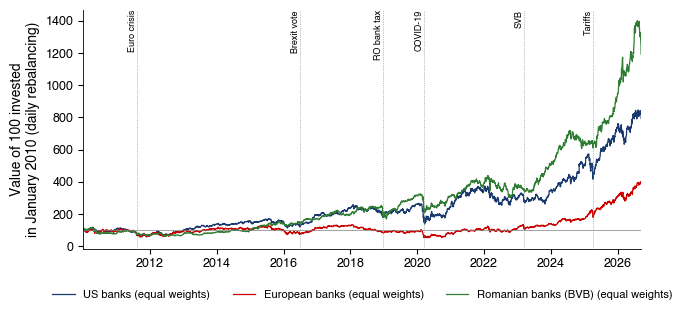

{'US': {'last': np.float64(791.4396458018049),
  'maxdd': -0.5134495497313767,
  'maxdd_date': Timestamp('2011-11-23 00:00:00'),
  'vol': np.float64(29.00594688646466),
  'peak_date': Timestamp('2026-08-14 00:00:00')},
 'EU': {'last': np.float64(383.9986901630275),
  'maxdd': -0.6074757993626247,
  'maxdd_date': Timestamp('2020-04-21 00:00:00'),
  'vol': np.float64(30.233310080260484),
  'peak_date': Timestamp('2026-09-08 00:00:00')},
 'RO': {'last': np.float64(1232.709040423833),
  'maxdd': -0.4682701412380772,
  'maxdd_date': Timestamp('2012-06-06 00:00:00'),
  'vol': np.float64(23.33081568342561),
  'peak_date': Timestamp('2026-08-04 00:00:00')}}

In [6]:
def fig_bank_indices():
    """Portofoliile bancare cu ponderi egale (SUA, Europa, Romania), baza 100 la inceputul lui 2010."""
    fig, ax = plt.subplots(figsize=(7.2, 3.1))
    out = {}
    for reg, mem in [('US', US), ('EU', EU), ('RO', RO)]:
        s = 100 * (1 + (np.exp(R[mem] / 100) - 1).mean(axis=1)).cumprod()     # rebalansare zilnica
        ax.plot(s.index, s.values, color=REGION_COL[reg], lw=0.9, label=f'{REGION_LAB[reg]} (equal weights)')
        dd = s / s.cummax() - 1
        out[reg] = {'last': s.iloc[-1], 'maxdd': dd.min(), 'maxdd_date': dd.idxmin(),
                    'vol': R[mem].mean(axis=1).std() * np.sqrt(252), 'peak_date': s.idxmax()}
    ax.axhline(100, color=Gray, lw=0.5)
    ax.set_ylabel('Value of 100 invested\nin January 2010 (daily rebalancing)')
    ax.set_xlim(R.index[0], R.index[-1])
    mark_events(ax)
    legend_outside_bottom(ax, ncol=3, y=-0.13)
    save_fig('ch18_bank_indices')
    return out


fig_bank_indices()

## 2. MES, LRMES and the break-even leverage

- MES 5% against the market index of each region, with a moving-block bootstrap.
- LRMES = 1 − exp(−18 × MES at the −2% threshold); break-even leverage L* = 1 + (1 − k)(1 − LRMES)/k, k = 8%.

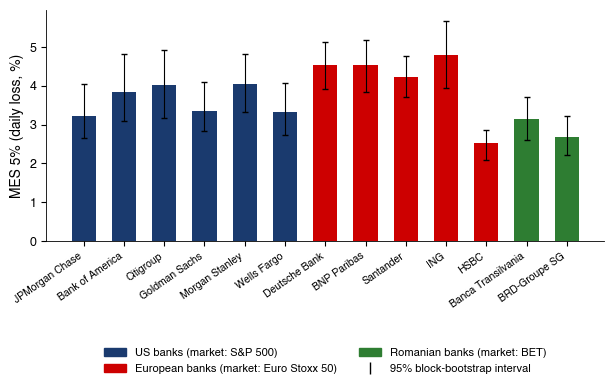

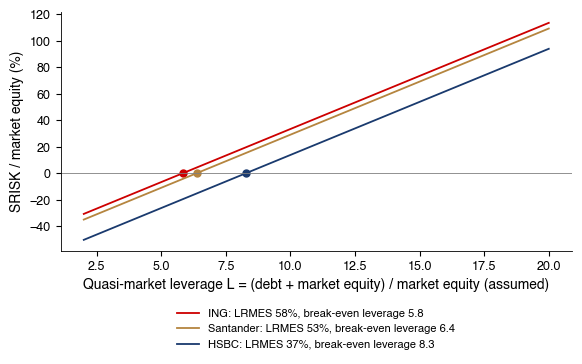

,mes5,lo,hi,mes2,n2,lrmes,Lstar,Lstar55,beta,es5_m,var1
JPM,3.219,2.662,4.048,3.613,138.0,0.478,7.002,9.967,1.154,2.721,4.829
BAC,3.846,3.089,4.824,4.382,138.0,0.546,6.226,8.808,1.326,2.721,5.988
C,4.030,3.163,4.923,4.580,138.0,0.561,6.043,8.534,1.420,2.721,5.868
GS,3.345,2.845,4.087,3.781,138.0,0.494,6.823,9.700,1.222,2.721,4.806
MS,4.039,3.321,4.811,4.616,138.0,0.564,6.010,8.485,1.444,2.721,5.827
WFC,3.320,2.725,4.073,3.786,138.0,0.494,6.817,9.691,1.178,2.721,5.780
DBK,4.540,3.929,5.123,4.547,196.0,0.559,6.073,8.579,1.385,3.163,7.189
BNP,4.534,3.834,5.179,4.541,196.0,0.558,6.079,8.588,1.392,3.163,6.182
SAN,4.230,3.702,4.769,4.236,196.0,0.533,6.365,9.016,1.371,3.163,5.828
INGA,4.805,3.940,5.671,4.820,196.0,0.580,5.829,8.216,1.442,3.163,7.163


In [7]:
def mes_table():
    """MES 5% (fata de indicele regional), MES la pragul de -2% si LRMES, cu interval bootstrap pe blocuri."""
    rows = {}
    rng = np.random.default_rng(SEED)
    for k in ALL:
        m = R[REGION_INDEX[region_of(k)]].values
        x = R[k].values
        boot = []
        for _ in range(B_BOOT):
            idx = block_bootstrap_idx(len(x), 20, rng)
            boot.append(mes(x[idx], m[idx], 0.05))
        m2 = mes_threshold(x, m, -2.0)
        rows[k] = {'mes5': mes(x, m, 0.05), 'lo': np.percentile(boot, 2.5), 'hi': np.percentile(boot, 97.5),
                   'mes2': m2, 'n2': int((m < -2).sum()), 'lrmes': lrmes(m2), 'Lstar': breakeven_leverage(lrmes(m2)),
                   'Lstar55': breakeven_leverage(lrmes(m2), 0.055),
                   'beta': np.cov(x, m)[0, 1] / np.var(m, ddof=1), 'es5_m': -m[m <= np.quantile(m, 0.05)].mean(),
                   'var1': -np.quantile(x, 0.01)}
    return pd.DataFrame(rows).T


def fig_mes(t):
    fig, ax = plt.subplots(figsize=(7.2, 3.0))
    xs = np.arange(len(ALL))
    cols = [REGION_COL[region_of(k)] for k in ALL]
    ax.bar(xs, t['mes5'], color=cols, width=0.6)
    ax.errorbar(xs, t['mes5'], yerr=[t['mes5'] - t['lo'], t['hi'] - t['mes5']], fmt='none', ecolor='black',
                capsize=2, lw=0.8)
    ax.set_xticks(xs)
    ax.set_xticklabels([NAMES[k] for k in ALL], rotation=35, ha='right', fontsize=7.5)
    ax.set_ylabel('MES 5% (daily loss, %)')
    h = [plt.Rectangle((0, 0), 1, 1, color=REGION_COL[r]) for r in ['US', 'EU', 'RO']]
    lab = ['US banks (market: S&P 500)', 'European banks (market: Euro Stoxx 50)', 'Romanian banks (market: BET)']
    h.append(plt.Line2D([], [], color='black', marker='|', ls='', ms=8))
    lab.append('95% block-bootstrap interval')
    ax.legend(h, lab, loc='upper center', bbox_to_anchor=(0.5, -0.42), ncol=2, frameon=False)
    save_fig('ch18_mes')


def fig_srisk(t):
    """SRISK / capitalul de piata in functie de levier, pentru bancile cu LRMES maxim, median si minim."""
    order = t['lrmes'].sort_values()
    pick = [order.index[-1], order.index[len(order) // 2], order.index[0]]
    L = np.linspace(2, 20, 200)
    fig, ax = plt.subplots(figsize=(6.6, 3.1))
    for k, c in zip(pick, [IDAred, Amber, MainBlue]):
        lr = t.loc[k, 'lrmes']
        ax.plot(L, 100 * srisk_ratio(lr, L), color=c, lw=1.3,
                label=f'{NAMES[k]}: LRMES {100 * lr:.0f}%, break-even leverage {t.loc[k, "Lstar"]:.1f}')
        ax.plot(t.loc[k, 'Lstar'], 0, 'o', color=c, ms=5)
    ax.axhline(0, color=Gray, lw=0.6)
    ax.set_xlabel('Quasi-market leverage L = (debt + market equity) / market equity (assumed)')
    ax.set_ylabel('SRISK / market equity (%)')
    legend_outside_bottom(ax, ncol=1, y=-0.2)
    save_fig('ch18_srisk')
    return pick


mt = mes_table()
fig_mes(mt)
fig_srisk(mt)
mt.round(3)

## 3. CoVaR and ΔCoVaR

- System of bank i: equal-weighted portfolio of the other banks of the same region.
- Quantile regression at 1%; 95% intervals from a moving-block bootstrap (blocks of 20 days).

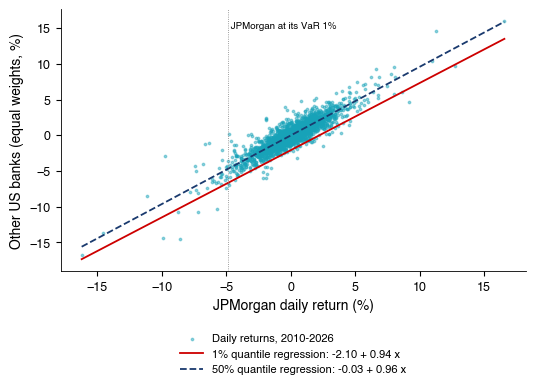

{0.01: (np.float64(-2.095957955340793), np.float64(0.9417207295768243)), 0.5: (np.float64(-0.027366245471438552), np.float64(0.9616821358131036))}


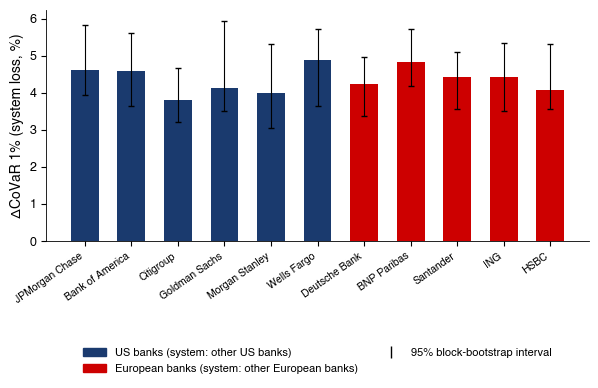

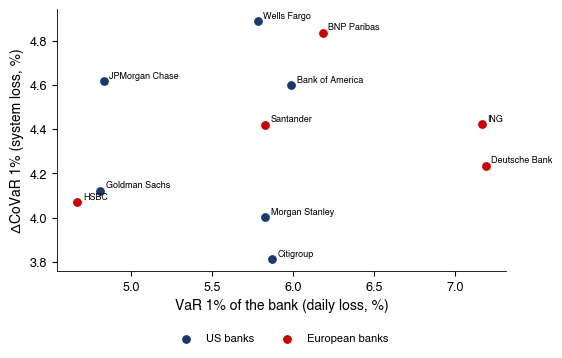

Spearman VaR vs ΔCoVaR: 0.16
Spearman 1% vs 5% rankings: 0.1


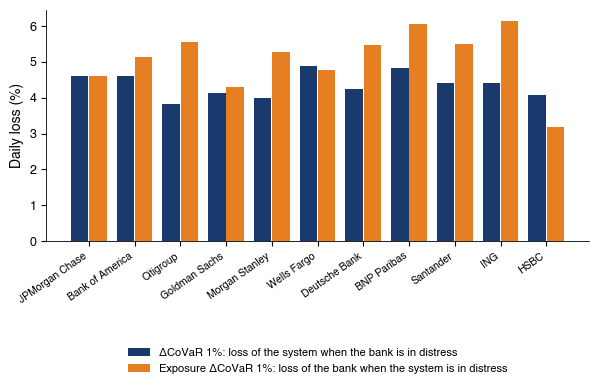

,a,b,var_i,covar,covar_med,dcovar,var_sys,lo,hi,exp_covar,exp_dcovar,exp_b
JPM,-2.10,0.94,4.83,6.64,2.03,4.62,5.07,3.96,5.83,6.77,4.61,0.90
BAC,-2.10,0.76,5.99,6.65,2.05,4.60,4.72,3.65,5.63,7.81,5.13,1.07
C,-2.35,0.64,5.87,6.13,2.32,3.81,4.82,3.23,4.69,8.23,5.55,1.13
GS,-2.52,0.85,4.81,6.59,2.46,4.12,5.05,3.52,5.95,6.86,4.29,0.84
MS,-2.60,0.68,5.83,6.56,2.55,4.00,4.98,3.07,5.33,7.91,5.29,1.05
WFC,-3.09,0.84,5.78,7.94,3.05,4.89,5.00,3.64,5.74,7.73,4.77,0.94
DBK,-2.97,0.59,7.19,7.19,2.96,4.24,5.15,3.38,4.97,9.49,5.48,1.05
BNP,-2.57,0.77,6.18,7.34,2.51,4.84,5.22,4.20,5.72,9.10,6.07,1.15
SAN,-3.02,0.75,5.83,7.40,2.98,4.42,5.39,3.58,5.10,8.87,5.49,1.01
INGA,-2.81,0.61,7.16,7.19,2.77,4.42,5.24,3.51,5.35,9.78,6.14,1.16


In [8]:
def fig_covar_qr():
    """Regresia cuantila a sistemului pe JPMorgan: dreptele de 1% si 50%."""
    xs, xi = system_ex('JPM', US), R['JPM']
    fig, ax = plt.subplots(figsize=(6.0, 3.4))
    ax.scatter(xi, xs, s=3, color=Teal, alpha=0.45, label='Daily returns, 2010-2026')
    grid = np.linspace(xi.min(), xi.max(), 50)
    out = {}
    for q, c, ls in [(0.01, IDAred, '-'), (0.5, MainBlue, '--')]:
        a, b = qreg(xs, xi, q)
        ax.plot(grid, a + b * grid, color=c, ls=ls, lw=1.3, label=f'{q:.0%} quantile regression: {a:.2f} + {b:.2f} x')
        out[q] = (a, b)
    qa = np.quantile(xi, 0.01)
    ax.axvline(qa, color=Gray, lw=0.6, ls=':')
    ax.text(qa, xs.max(), ' JPMorgan at its VaR 1%', fontsize=7, color='black', va='top')
    ax.set_xlabel('JPMorgan daily return (%)')
    ax.set_ylabel('Other US banks (equal weights, %)')
    legend_outside_bottom(ax, ncol=1, y=-0.2)
    save_fig('ch18_covar_qr')
    return out


def covar_table(alpha):
    """CoVaR si Delta-CoVaR pentru bancile americane si europene (sistemul = restul bancilor din regiune)."""
    rows = {}
    for i, k in enumerate(US + EU):
        mem = US if k in US else EU
        xs = system_ex(k, mem)
        c = covar_static(xs, R[k], alpha)
        lo, hi = covar_boot(xs, R[k], alpha, B=B_BOOT, block=20, seed=SEED + i)
        e = covar_static(R[k], xs, alpha)                      # expunerea: banca in conditiile unei crize a sistemului
        rows[k] = {**c, 'lo': lo, 'hi': hi, 'exp_covar': e['covar'], 'exp_dcovar': e['dcovar'], 'exp_b': e['b']}
    return pd.DataFrame(rows).T


def fig_dcovar(t):
    ks = list(t.index)
    xs = np.arange(len(ks))
    fig, ax = plt.subplots(figsize=(7.0, 3.0))
    ax.bar(xs, t['dcovar'], color=[REGION_COL[region_of(k)] for k in ks], width=0.6)
    ax.errorbar(xs, t['dcovar'], yerr=[t['dcovar'] - t['lo'], t['hi'] - t['dcovar']], fmt='none', ecolor='black',
                capsize=2, lw=0.8)
    ax.set_xticks(xs)
    ax.set_xticklabels([NAMES[k] for k in ks], rotation=35, ha='right', fontsize=7.5)
    ax.set_ylabel('ΔCoVaR 1% (system loss, %)')
    h = [plt.Rectangle((0, 0), 1, 1, color=REGION_COL[r]) for r in ['US', 'EU']] + \
        [plt.Line2D([], [], color='black', marker='|', ls='', ms=8)]
    ax.legend(h, ['US banks (system: other US banks)', 'European banks (system: other European banks)',
                  '95% block-bootstrap interval'], loc='upper center', bbox_to_anchor=(0.5, -0.42), ncol=2,
              frameon=False)
    save_fig('ch18_dcovar')


def fig_var_vs_dcovar(t):
    fig, ax = plt.subplots(figsize=(5.8, 3.4))
    for reg in ['US', 'EU']:
        s = t[[region_of(k) == reg for k in t.index]]
        ax.scatter(s['var_i'], s['dcovar'], s=28, color=REGION_COL[reg], label=REGION_LAB[reg], zorder=3)
        for k in s.index:
            ax.annotate(NAMES[k], (s.loc[k, 'var_i'], s.loc[k, 'dcovar']), xytext=(4, 2), textcoords='offset points',
                        fontsize=6.5, color='black')
    ax.set_xlabel('VaR 1% of the bank (daily loss, %)')
    ax.set_ylabel('ΔCoVaR 1% (system loss, %)')
    legend_outside_bottom(ax, ncol=2, y=-0.2)
    save_fig('ch18_var_vs_dcovar')
    from scipy.stats import spearmanr
    return spearmanr(t['var_i'], t['dcovar']).correlation


def fig_exposure(t):
    ks = list(t.index)
    xs = np.arange(len(ks))
    fig, ax = plt.subplots(figsize=(7.0, 3.0))
    ax.bar(xs - 0.2, t['dcovar'], 0.38, color=MainBlue, label='ΔCoVaR 1%: loss of the system when the bank is in distress')
    ax.bar(xs + 0.2, t['exp_dcovar'], 0.38, color=Orange, label='Exposure ΔCoVaR 1%: loss of the bank when the system is in distress')
    ax.set_xticks(xs)
    ax.set_xticklabels([NAMES[k] for k in ks], rotation=35, ha='right', fontsize=7.5)
    ax.set_ylabel('Daily loss (%)')
    legend_outside_bottom(ax, ncol=1, y=-0.42)
    save_fig('ch18_exposure')


print(fig_covar_qr())
c1 = covar_table(0.01)
c5 = covar_table(0.05)
fig_dcovar(c1)
print('Spearman VaR vs ΔCoVaR:', round(fig_var_vs_dcovar(c1), 2))
print('Spearman 1% vs 5% rankings:', round(spearmanr(c1['dcovar'], c5['dcovar']).correlation, 2))
fig_exposure(c1)
c1.round(2)

## 4. ΔCoVaR over time

- State variables at t − 1: log VIX, regional index return, system return.

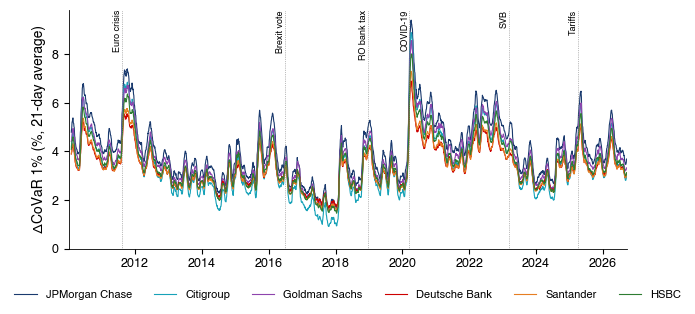

,JPM,C,GS,DBK,SAN,HSBA
mean,4.10,3.46,3.78,3.37,3.37,3.55
2017,2.16,1.43,1.98,2.04,1.93,1.89
March 2020,9.06,8.51,8.10,6.65,7.02,7.61


In [9]:
def dynamic_covar():
    """Delta-CoVaR 1% variabil in timp; stare: log VIX, randamentul indicelui regional si al sistemului (t-1)."""
    out, betas = {}, {}
    for k in ['JPM', 'C', 'GS', 'DBK', 'SAN', 'HSBA']:
        mem = US if k in US else EU
        xs = system_ex(k, mem)
        Mv = pd.concat([np.log(index_close('VIX')).reindex(R.index).ffill(), R[REGION_INDEX[region_of(k)]], xs],
                       axis=1).shift(1)
        d = pd.concat([xs.rename('sys'), R[k].rename('x'), Mv], axis=1).dropna()
        f, b = covar_dynamic(d['sys'], d['x'], d.iloc[:, 2:].values, 0.01)
        f.index = d.index
        out[k], betas[k] = f, b
    return out, betas


def fig_dcovar_dynamic(dyn):
    fig, ax = plt.subplots(figsize=(7.2, 3.1))
    cols = {'JPM': MainBlue, 'C': Teal, 'GS': Purple, 'DBK': IDAred, 'SAN': Orange, 'HSBA': Forest}
    for k, f in dyn.items():
        s = f['dcovar'].rolling(21).mean()
        ax.plot(s.index, s.values, color=cols[k], lw=0.8, label=NAMES[k])
    ax.set_ylabel('ΔCoVaR 1% (%, 21-day average)')
    ax.set_xlim(R.index[0], R.index[-1])
    ax.set_ylim(bottom=0)
    mark_events(ax)
    legend_outside_bottom(ax, ncol=6, y=-0.13)
    save_fig('ch18_dcovar_dynamic')


dyn, betas = dynamic_covar()
fig_dcovar_dynamic(dyn)
pd.DataFrame({k: {'mean': f['dcovar'].mean(), '2017': f['dcovar'].loc['2017'].mean(), 'March 2020': f['dcovar'].loc['2020-03'].mean()} for k, f in dyn.items()}).round(2)

## 5. Diebold–Yilmaz connectedness

- VAR on the log Parkinson volatility of 13 banks, generalized variance decomposition at 10 days.

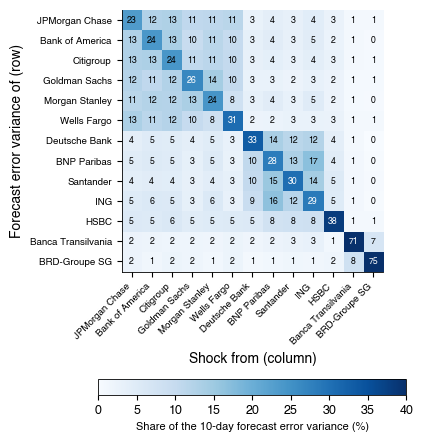

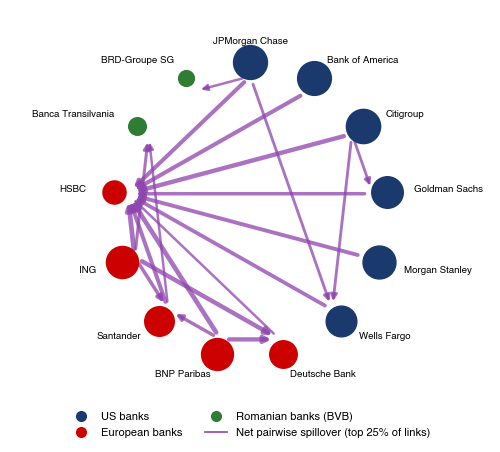

VAR order 1 | total connectedness 64.8 | on returns 75.4


,to,from,net
JPM,89.4,76.8,12.6
BAC,88.4,76.0,12.4
C,91.4,75.8,15.6
GS,76.1,73.5,2.5
MS,83.6,75.7,7.9
WFC,71.3,69.2,2.1
DBK,55.4,66.7,-11.3
BNP,78.0,71.8,6.2
SAN,65.6,69.6,-4.0
INGA,79.0,71.5,7.5


In [10]:
def spill_static(H=10):
    p = var_bic(V.values, 5)
    A, S = var_fit(V.values, p)
    st = spillover_table(gfevd(A, S, H), ALL)
    ret = R[ALL]
    pr = var_bic(ret.values, 5)
    Ar, Sr = var_fit(ret.values, pr)
    st_r = spillover_table(gfevd(Ar, Sr, H), ALL)
    return st, p, st_r, pr


def fig_spill_table(st):
    tab = st['table']
    fig, ax = plt.subplots(figsize=(7.2, 5.0))
    im = ax.imshow(tab.values, cmap='Blues', vmin=0, vmax=40)
    for i in range(len(ALL)):
        for j in range(len(ALL)):
            v = tab.values[i, j]
            ax.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=6.3, color='white' if v > 25 else 'black')
    ax.set_xticks(range(len(ALL)))
    ax.set_yticks(range(len(ALL)))
    ax.set_xticklabels([NAMES[k] for k in ALL], rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels([NAMES[k] for k in ALL], fontsize=7)
    ax.set_xlabel('Shock from (column)')
    ax.set_ylabel('Forecast error variance of (row)')
    cb = fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.04, pad=0.28)
    cb.set_label('Share of the 10-day forecast error variance (%)', fontsize=8)
    save_fig('ch18_spill_table')


def fig_spill_network(st):
    """Reteaua conectivitatii nete pe perechi: sageata de la emitator la receptor, grosime ~ efectul net."""
    pn = st['pairwise_net']                     # pn[i, j] > 0: i transmite net catre j
    n = len(ALL)
    ang = np.linspace(np.pi / 2, np.pi / 2 - 2 * np.pi, n, endpoint=False)
    pos = {k: (np.cos(a), np.sin(a)) for k, a in zip(ALL, ang)}
    thr = np.quantile(pn.values[pn.values > 0], 0.75)
    fig, ax = plt.subplots(figsize=(6.2, 5.2))
    for i in ALL:
        for j in ALL:
            v = pn.loc[i, j]
            if v > thr:
                (x0, y0), (x1, y1) = pos[i], pos[j]
                ax.annotate('', xy=(x1 * 0.9, y1 * 0.9), xytext=(x0 * 0.9, y0 * 0.9),
                            arrowprops=dict(arrowstyle='-|>', color=Purple, lw=0.4 + 0.9 * v, alpha=0.75,
                                            shrinkA=6, shrinkB=6))
    to = st['to']
    for k in ALL:
        x, y = pos[k]
        ax.scatter(x, y, s=60 + 6 * to[k], color=REGION_COL[region_of(k)], zorder=3)
        ax.text(1.2 * x, 1.14 * y, NAMES[k], ha='left' if x > 0.2 else ('right' if x < -0.2 else 'center'),
                va='center', fontsize=7, color='black')
    ax.set_xlim(-1.75, 1.75)
    ax.set_ylim(-1.35, 1.35)
    ax.axis('off')
    h = [plt.Line2D([], [], marker='o', ls='', color=REGION_COL[r], ms=7) for r in ['US', 'EU', 'RO']]
    h.append(plt.Line2D([], [], color=Purple, lw=1.2))
    ax.legend(h, [REGION_LAB[r] for r in ['US', 'EU', 'RO']] + ['Net pairwise spillover (top 25% of links)'],
              loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2, frameon=False)
    save_fig('ch18_spill_network')
    return thr


st, p, st_r, pr = spill_static()
fig_spill_table(st)
fig_spill_network(st)
print('VAR order', p, '| total connectedness', round(st['total'], 1), '| on returns', round(st_r['total'], 1))
pd.DataFrame({'to': st['to'], 'from': st['from'], 'net': st['net']}).round(1)

## 6. Connectedness over time

- 250-day windows, every 5 days, VAR(2), H = 10.

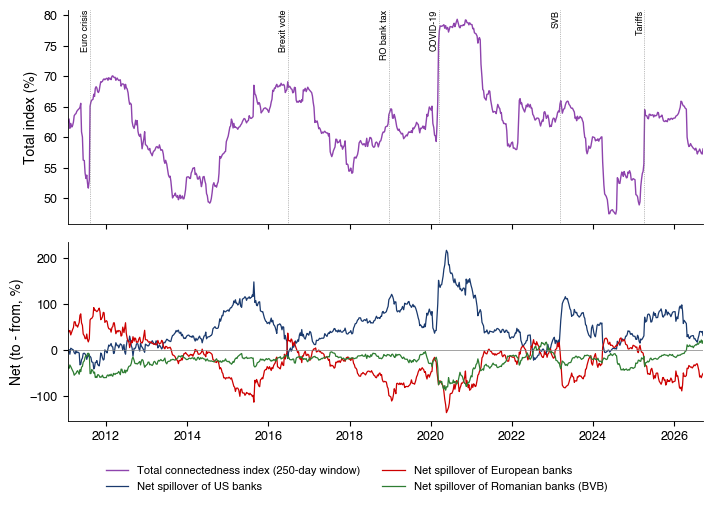

count    744.0
mean      62.0
std        6.6
min       47.4
25%       58.2
50%       62.3
75%       65.4
max       79.3
dtype: float64

In [11]:
def spill_rolling():
    tot, net = rolling_total(V, window=250, step=5, p=2, H=10)
    return tot, net


def fig_spill_rolling(tot, net):
    fig, axes = plt.subplots(2, 1, figsize=(7.2, 4.6), sharex=True, gridspec_kw={'height_ratios': [1.2, 1]})
    axes[0].plot(tot.index, tot.values, color=Purple, lw=1.0, label='Total connectedness index (250-day window)')
    axes[0].set_ylabel('Total index (%)')
    axes[0].set_xlim(tot.index[0], tot.index[-1])
    mark_events(axes[0])
    for reg in ['US', 'EU', 'RO']:
        mem = [k for k in ALL if region_of(k) == reg]
        s = net[mem].sum(axis=1)
        axes[1].plot(s.index, s.values, color=REGION_COL[reg], lw=0.9, label=f'Net spillover of {REGION_LAB[reg]}')
    axes[1].axhline(0, color=Gray, lw=0.5)
    axes[1].set_ylabel('Net (to - from, %)')
    fig.tight_layout()
    h = axes[0].get_lines()[:1] + axes[1].get_lines()[:3]
    fig.legend(h, [l.get_label() for l in h], loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=2, frameon=False)
    save_fig('ch18_spill_rolling')


tot, net = spill_rolling()
fig_spill_rolling(tot, net)
tot.describe().round(1)

## 7. Financial Risk Meter

- L1-penalized quantile regression at 5% on 63-day windows; penalty chosen by GACV.
- The rolling series takes a few minutes (390 windows × 13 banks).

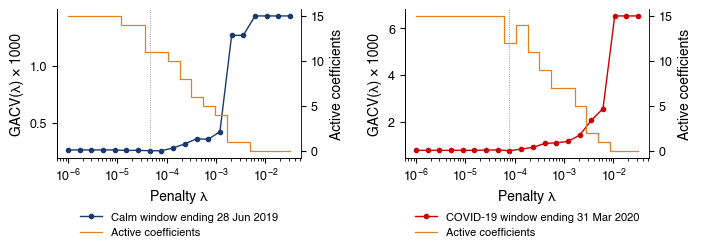

{'2019-06-28': {'lambda': np.float64(4.548777947003778e-05), 'df': 11, 'gacv_min': np.float64(0.0002539998997612978)}, '2020-03-31': {'lambda': np.float64(7.847599703514606e-05), 'df': 12, 'gacv_min': np.float64(0.0007708372919225498)}}


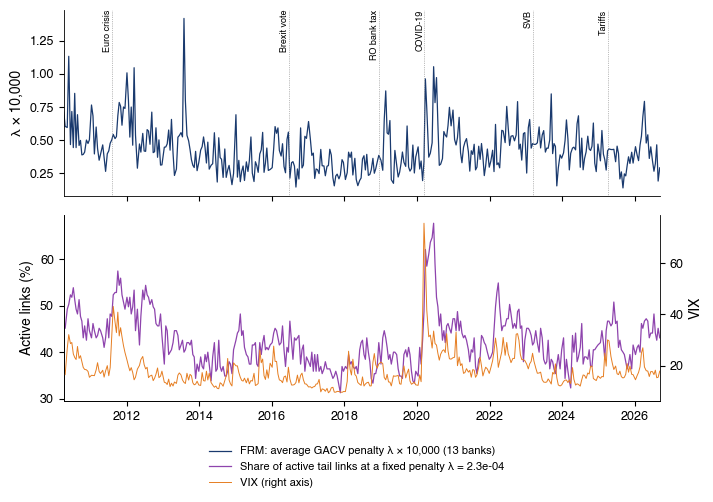

{'corr_frm_vix': np.float64(0.3488727381342896), 'corr_dens_vix': np.float64(0.6199655732817195), 'frm_mean': np.float64(4.318224717783507e-05), 'dens_mean': np.float64(0.4244444444444445), 'dens_max': 0.6769230769230768, 'dens_max_date': Timestamp('2020-06-17 00:00:00'), 'dens_min': 0.3128205128205129, 'dens_min_date': Timestamp('2017-11-21 00:00:00'), 'n_windows': 390}


In [12]:
def frm_design():
    """Randamente zilnice (fractii) ale bancilor si variabilele macro intarziate cu o zi."""
    Rf = R / 100
    Mac = Rf[MACRO].shift(1).add_suffix('_lag')
    return Rf[ALL].join(Mac).dropna()


def frm_window(D, k, tau=0.05):
    X = D[[j for j in ALL if j != k] + [c for c in D.columns if c.endswith('_lag')]]
    return lasso_qr_gacv(D[k].values, X.values, tau, LAMBDAS)


def frm_series(window=63, step=10, lam_fixed=2e-4):
    """FRM = media lambda (GACV) pe banci, pe ferestre mobile de 63 de zile; si densitatea legaturilor la lambda fix."""
    D = frm_design()
    rows = {}
    cache = os.path.join(HERE, 'ch18_frm.csv')
    if os.environ.get('MFM_FRM_CACHE') and os.path.exists(cache):
        return pd.read_csv(cache, index_col=0, parse_dates=True), LAMBDAS[int(np.argmin(np.abs(LAMBDAS - lam_fixed)))]
    j_fix = int(np.argmin(np.abs(LAMBDAS - lam_fixed)))
    for end in range(window, len(D) + 1, step):
        w = D.iloc[end - window:end]
        lam, dens = [], []
        for k in ALL:
            r = frm_window(w, k)
            lam.append(r['lambda'])
            dens.append(r['df'][j_fix] / (len(ALL) - 1 + len(MACRO)))
        rows[D.index[end - 1]] = {'frm': np.mean(lam), 'density': np.mean(dens)}
    f = pd.DataFrame(rows).T
    f.to_csv(os.path.join(HERE, 'ch18_frm.csv'))
    return f, LAMBDAS[j_fix]


def fig_frm_gacv():
    """Curba GACV pentru JPMorgan intr-o fereastra calma si intr-una de criza."""
    D = frm_design()
    out = {}
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.8))
    for ax, (end, lab, c) in zip(axes, [('2019-06-28', 'Calm window ending 28 Jun 2019', MainBlue),
                                        ('2020-03-31', 'COVID-19 window ending 31 Mar 2020', IDAred)]):
        w = D.loc[:end].iloc[-63:]
        r = frm_window(w, 'JPM')
        ax.plot(LAMBDAS, 1e3 * np.array(r['gacv']), 'o-', color=c, ms=3, lw=1, label=lab)
        ax.axvline(r['lambda'], color=Gray, lw=0.6, ls=':')
        ax.set_xscale('log')
        ax.set_xlabel('Penalty λ')
        ax.set_ylabel('GACV(λ) × 1000')
        ax2 = ax.twinx()
        ax2.step(LAMBDAS, r['df'], where='mid', color=Orange, lw=0.9, label='Active coefficients')
        ax2.set_ylabel('Active coefficients')
        ax2.spines['right'].set_visible(True)
        h = ax.get_lines()[:1] + ax2.get_lines()[:1]
        ax.legend(h, [l.get_label() for l in h], loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=1, frameon=False)
        out[end] = {'lambda': r['lambda'], 'df': r['df_sel'], 'gacv_min': min(r['gacv'])}
    fig.tight_layout()
    save_fig('ch18_frm_gacv')
    return out


def fig_frm_rolling(f, lam_fix):
    vix = index_close('VIX').reindex(f.index)
    fig, axes = plt.subplots(2, 1, figsize=(7.2, 4.4), sharex=True)
    axes[0].plot(f.index, 1e4 * f['frm'], color=MainBlue, lw=0.9, label='FRM: average GACV penalty λ × 10,000 (13 banks)')
    axes[0].set_ylabel('λ × 10,000')
    axes[1].plot(f.index, 100 * f['density'], color=Purple, lw=0.9,
                 label=f'Share of active tail links at a fixed penalty λ = {lam_fix:.1e}')
    axes[1].set_ylabel('Active links (%)')
    ax3 = axes[1].twinx()
    ax3.plot(vix.index, vix.values, color=Orange, lw=0.7, label='VIX (right axis)')
    ax3.spines['right'].set_visible(True)
    ax3.set_ylabel('VIX')
    axes[0].set_xlim(f.index[0], f.index[-1])
    mark_events(axes[0])
    fig.tight_layout()
    h = axes[0].get_lines()[:1] + axes[1].get_lines()[:1] + ax3.get_lines()[:1]
    fig.legend(h, [l.get_label() for l in h], loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=1, frameon=False)
    save_fig('ch18_frm_rolling')
    return {'corr_frm_vix': f['frm'].corr(vix), 'corr_dens_vix': f['density'].corr(vix),
            'frm_mean': f['frm'].mean(), 'dens_mean': f['density'].mean(),
            'dens_max': f['density'].max(), 'dens_max_date': f['density'].idxmax(),
            'dens_min': f['density'].min(), 'dens_min_date': f['density'].idxmin(), 'n_windows': len(f)}


print(fig_frm_gacv())
f, lam_fix = frm_series()
print(fig_frm_rolling(f, lam_fix))

## 8. Stress tests

- Historical: worst 10 days of the equal-weighted bank portfolio in seven episodes.
- Reverse: most plausible factor scenario for a 25% loss over four weeks.

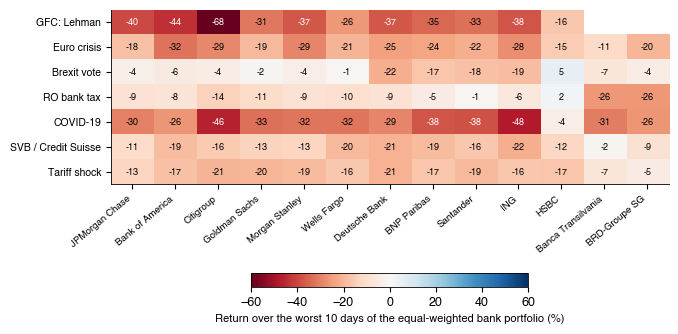

                          loss                start                  end  \
GFC: Lehman           38.34179  2008-11-10 00:00:00  2008-11-21 00:00:00   
Euro crisis          22.727188  2011-07-26 00:00:00  2011-08-10 00:00:00   
Brexit vote           8.201857  2016-06-22 00:00:00  2016-07-06 00:00:00   
RO bank tax          10.551312  2018-12-10 00:00:00  2018-12-21 00:00:00   
COVID-19             32.489364  2020-03-05 00:00:00  2020-03-18 00:00:00   
SVB / Credit Suisse  14.979719  2023-03-07 00:00:00  2023-03-20 00:00:00   
Tariff shock         16.133463  2025-03-25 00:00:00  2025-04-07 00:00:00   

                    n_banks  
GFC: Lehman              11  
Euro crisis              13  
Brexit vote              13  
RO bank tax              13  
COVID-19                 13  
SVB / Credit Suisse      13  
Tariff shock             13  


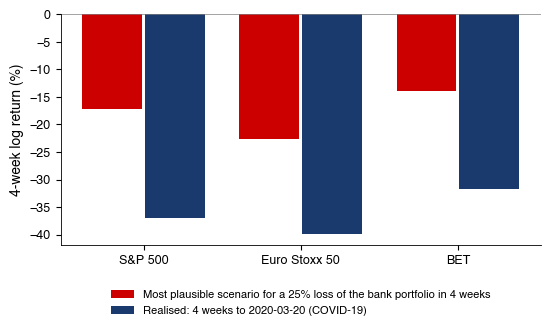

{'b': array([0.45317786, 0.65159282, 0.18021185]),
 'fstar': array([-17.16189976, -22.59486497, -13.8723129 ]),
 'd': np.float64(4.314402783533824),
 'p': np.float64(8.001746877289543e-06),
 'real': array([-37.0251002 , -39.95961109, -31.78650042]),
 'real_loss': np.float64(51.980238875235464)}

In [13]:
def stress_historical():
    """Pentru fiecare episod: cea mai proasta fereastra de 10 zile a portofoliului bancar cu ponderi egale."""
    Rl = joint_returns(INTL, start='2007-01-01')
    rows, port = {}, {}
    for name, a, b in EPISODES:
        keys = INTL + (RO if pd.Timestamp(a) >= pd.Timestamp('2010-01-01') else [])
        X = (Rl.loc[a:b] if keys == INTL else R.loc[a:b, keys])
        p = X.mean(axis=1).rolling(10).sum()
        end = p.idxmin()
        i = X.index.get_loc(end)
        win = X.iloc[i - 9:i + 1]
        cum = 100 * (np.exp(win.sum() / 100) - 1)
        rows[name] = cum.reindex(ALL)
        port[name] = {'loss': -100 * (np.exp(p.min() / 100) - 1), 'start': win.index[0], 'end': win.index[-1],
                      'n_banks': len(keys)}
    return pd.DataFrame(rows).T, port


def fig_stress_hist(H):
    fig, ax = plt.subplots(figsize=(7.2, 3.6))
    im = ax.imshow(H.values, cmap='RdBu', vmin=-60, vmax=60, aspect='auto')
    for i in range(H.shape[0]):
        for j in range(H.shape[1]):
            v = H.values[i, j]
            ax.text(j, i, '' if np.isnan(v) else f'{v:.0f}', ha='center', va='center', fontsize=6.5,
                    color='white' if abs(v) > 35 else 'black')
    ax.set_xticks(range(H.shape[1]))
    ax.set_xticklabels([NAMES[k] for k in H.columns], rotation=40, ha='right', fontsize=7)
    ax.set_yticks(range(H.shape[0]))
    ax.set_yticklabels(H.index, fontsize=7.5)
    cb = fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.05, pad=0.32)
    cb.set_label('Return over the worst 10 days of the equal-weighted bank portfolio (%)', fontsize=8)
    save_fig('ch18_stress_hist')


def weekly_returns(keys):
    p = prices(keys)
    w = p.resample('W-FRI').last().dropna()
    return 100 * np.log(w).diff().dropna()


def reverse_stress(target=25.0, weeks=4):
    """Testul de stres invers: cel mai plauzibil scenariu al factorilor care produce o pierdere data.

    Model: randamentele saptamanale ale bancilor = beta' f + eroare, f = (S&P 500, Euro Stoxx 50, BET);
    pe orizontul de h saptamani f ~ N(0, h Sigma). Pierderea portofoliului L = -b'f, b = media beta.
    Scenariul cel mai probabil cu L = target: f* = -target Sigma b / (b' Sigma b); distanta Mahalanobis target / sqrt(b' Sigma b)."""
    W = weekly_returns(ALL + ['SPX', 'SX5E', 'BET'])
    F = W[['SPX', 'SX5E', 'BET']]
    Xf = np.column_stack([np.ones(len(F)), F.values])
    betas = {k: np.linalg.lstsq(Xf, W[k].values, rcond=None)[0][1:] for k in ALL}
    b = np.mean([betas[k] for k in ALL], axis=0)
    S = weeks * F.cov().values
    sb = np.sqrt(b @ S @ b)
    fstar = -target * S @ b / sb ** 2
    d = target / sb
    from scipy.stats import norm
    # miscarile realizate ale factorilor in cele mai proaste 4 saptamani ale portofoliului (2020)
    port = W[ALL].mean(axis=1).rolling(weeks).sum()
    end = port.loc['2020'].idxmin()
    real = F.loc[:end].iloc[-weeks:].sum()
    return {'b': b, 'fstar': fstar, 'd': d, 'p': norm.cdf(-d), 'sigma_p': sb, 'target': target,
            'betas': {k: v for k, v in betas.items()}, 'real': real.values, 'real_loss': -port.loc[end],
            'real_end': end, 'real_model_loss': -b @ real.values, 'n_weeks': len(W)}


def fig_reverse(rv):
    fig, ax = plt.subplots(figsize=(6.2, 3.0))
    xs = np.arange(3)
    ax.bar(xs - 0.2, rv['fstar'], 0.38, color=IDAred,
           label=f'Most plausible scenario for a {rv["target"]:.0f}% loss of the bank portfolio in 4 weeks')
    ax.bar(xs + 0.2, rv['real'], 0.38, color=MainBlue, label=f'Realised: 4 weeks to {rv["real_end"].date()} (COVID-19)')
    ax.axhline(0, color=Gray, lw=0.5)
    ax.set_xticks(xs)
    ax.set_xticklabels(['S&P 500', 'Euro Stoxx 50', 'BET'])
    ax.set_ylabel('4-week log return (%)')
    legend_outside_bottom(ax, ncol=1, y=-0.15)
    save_fig('ch18_reverse_stress')


H, port = stress_historical()
fig_stress_hist(H)
print(pd.DataFrame(port).T)
rv = reverse_stress()
fig_reverse(rv)
{k: rv[k] for k in ['b', 'fstar', 'd', 'p', 'real', 'real_loss']}

## Summary

- Exposure (MES, SRISK), contribution (ΔCoVaR) and connectedness (spillover and tail networks) answer different questions.
- Rankings of banks are uncertain: always report bootstrap intervals.